### Demonstration: Valuating a battery against the power market

#### Import required packages

In [3]:
# imports
import pandas as pd
import seaborn as sns
import datetime as dt
import eaopack as eao
import matplotlib.pyplot as plt

#### Set main parameters

In [18]:
Start = dt.datetime(2024, 1, 1)
End   = dt.datetime(2024, 1, 2)
Start = pd.Timestamp(Start).tz_localize('CET')
End   = pd.Timestamp(End).tz_localize('CET')

load_from_file = True

#### Load price data

For the demo already saved in pickle file -- but all required data publicly available via API

In [6]:
##### load data
if load_from_file:
    data      = pd.read_pickle('./notebooks/tools/data_DAH_ID.pkl')
    data_FCR = pd.read_pickle('./notebooks/tools/FCR_price.pkl')    
else:      
    ############ read from APIs
    import sys
    sys.path.insert(1, 'C:/Users/Tobias/Documents/code/data_importer')
    import importer_netztransparenz as nt
    import import_regelenergie as RE
    ######## power prices
    c    = nt.NetzTransparenz()
    data = c.get_data(keys = ['dah', 'id_aep'], start=Start, end = End, freq = '15min')    
    data.rename(columns={'dah':'dah', 'id_aep':'id'}, inplace=True)
    data.index = data.index.tz_convert('CET')
    data.to_pickle('data_DAH_ID.pkl')
    ######## FCR prices
    c = RE.Regelenergie()
    df = c._get_data_key(key = 'FCR_price', start=Start, end = End)   
    # format data
    df.set_index('DATE_TO', inplace=True)
    df.index = df.index.tz_localize('CET')
    # filter
    df = df.loc[df ['TENDER_NUMBER']==1,:] # only tender 1
    # get duration of products
    df['hour_start'] = df['PRODUCTNAME'].str.split('_').str[1]
    df['hour_end'] = df['PRODUCTNAME'].str.split('_').str[2]
    df['duration'] = df['hour_end'].astype(int) - df['hour_start'].astype(int)
    colDE = 'GERMANY_SETTLEMENTCAPACITY_PRICE_[EUR/MW]'
    colCross = 'CROSSBORDER_SETTLEMENTCAPACITY_PRICE_[EUR/MW]'
    df['price_DE_normed'] = df[colDE] 
    df.loc[df['price_DE_normed'].isna(), 'price_DE_normed'] =df.loc[df['price_DE_normed'].isna(), colCross] 
    df['price_DE_normed'] /= df['duration']
    # average for days across products
    data_FCR = df.groupby(df.index)['price_DE_normed'].mean()
    print(data_FCR.head())
    data_FCR.to_pickle('FCR_price.pkl')

##### Show some sample market prices
Note that there is intense volatility particularly in the intraday market. That's where flexibility's value is generated

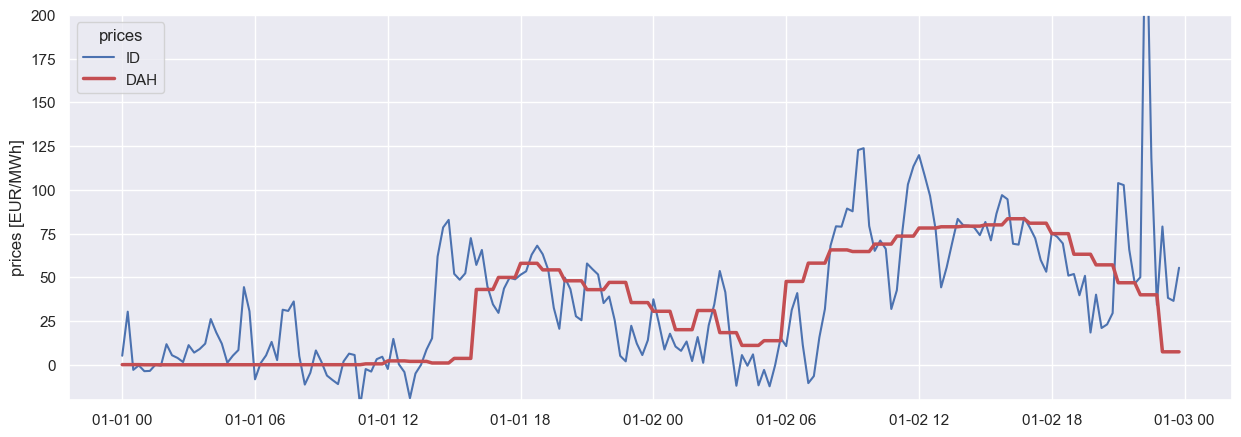

In [11]:
# plot market prices
s = '2024-01-01' 
e = '2024-01-02'
sns.set_theme()
sns.color_palette("light:b", as_cmap=True)
sns.set_context("notebook") #talk, poster, notebook, paper
fig,ax = plt.subplots(figsize = (15,5))
g = sns.lineplot(data = data.loc[s:e,:].reset_index(), x='index', y = 'id', color='b', ax=ax, label = 'ID')
h = sns.lineplot(data = data.loc[s:e,:].reset_index(), x='index', y = 'dah', color='r', ax=ax, label = 'DAH', linewidth=2.5)
ax.set_ylim(-20, 200)
ax.set_xlabel(None)
ax.set_ylabel("prices [EUR/MWh]")
ax.legend(title= "prices", loc='upper left')
plt.show()

#### Prepare valuation: Defining the battery's main technical data
Note that here we use a slightly simplified setup for demonstration purposes. More parameters can be defined

In [19]:
# define battery parameters
battery_data = {} # capacity, size and efficiency of an on-site battery
battery_data['cap']              =  1 # MW
battery_data['size']             =  2 * battery_data['cap'] # ... hours
battery_data['eff']              =  0.9 # 90% cycle efficiency
battery_data['no_simult_in_out'] = True # no simultaneous in and out (as could be done in some hydro storages)
# let us start without cycle limits to see what the battery "wants" to do
battery_data['max_cycle']        = 1 #  max. number of cycles per day
battery_data['freq_cycle']       = 'd'


In order to use our optimization package, we generate the portfolio out of
* battery
* market

Here we generate a portfolio for DAH and for ID optimization

In [20]:
### Structural setup, distinguishing own assets and supply from the grid
node_power    = eao.assets.Node('power')
### market - buy and sell. We can also add spreads and limits
dah = eao.assets.SimpleContract(   name       = 'dah', 
                                   nodes      = node_power,
                                   price      = 'dah',
                                   min_cap    = -1000,
                                   max_cap    =  1000)
id  = eao.assets.SimpleContract(   name       = 'id', 
                                   nodes      = node_power,
                                   price      = 'id',
                                   min_cap    = -1000,
                                   max_cap    =  1000)
### Our battery
battery     = eao.assets.Storage(  name       = 'battery',
                                   nodes      = node_power,
                                   cap_in     = battery_data['cap'],
                                   cap_out    = battery_data['cap'],                                        
                                   eff_in     = battery_data['eff'],
                                   size       = battery_data['size'],
                                   start_level= 0 * battery_data['size'],
                                   end_level  = 0 * battery_data['size'],
                                   max_cycles_no   =  battery_data['max_cycle'],
                                   max_cycles_freq = battery_data['freq_cycle'],
                                   no_simult_in_out= battery_data['no_simult_in_out'],
                                   block_size = None)   # can be used to speed up
### set up portfolios
portf_dah = eao.portfolio.Portfolio([dah, battery])
portf_id  = eao.portfolio.Portfolio([id, battery])

### timegrid for optimization
tg_dah = eao.basic_classes.Timegrid(start=Start, end=End, freq='h', timezone='CET')
tg_id  = eao.basic_classes.Timegrid(start=Start, end=End, freq='15min', timezone='CET')

In case of complex portfolios, network charts can be generated. In our case very simple...

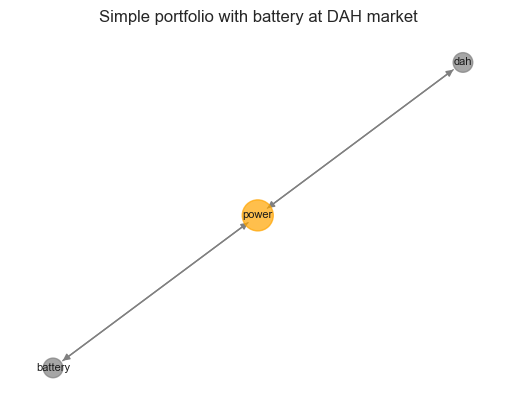

In [21]:
eao.network_graphs.create_graph(portf_dah, title="Simple portfolio with battery at DAH market",)

### Optimize!
We pass our portfolios with price data to the optimizer (that's all...)
* Optimizer builds a MIP
* Connects to the solver (here SCIP, also Guroby, CPLEX, etc. possible)

To speed up: We cut optimization into daily optimization for the demo. Longer times naturally possible up to some limit

In [22]:
# start optimizer
out_dah = eao.optimize(portf_dah, timegrid=tg_dah, data = data, split_interval_size='d')
out_id  = eao.optimize(portf_id,  timegrid=tg_id,  data = data, split_interval_size='d') 

In [30]:
out_id['dispatch']

,id,battery
2024-01-01 00:00:00+01:00,0.0,0.0
2024-01-01 00:15:00+01:00,0.0,0.0
2024-01-01 00:30:00+01:00,0.0,0.0
2024-01-01 00:45:00+01:00,0.0,0.0
2024-01-01 01:00:00+01:00,0.0,0.0
...,...,...
2024-01-01 22:45:00+01:00,0.0,0.0
2024-01-01 23:00:00+01:00,0.0,0.0
2024-01-01 23:15:00+01:00,0.0,0.0
2024-01-01 23:30:00+01:00,0.0,0.0


In [28]:
out_id['prices']

,input data: id,input data: dah
2024-01-01 00:00:00+01:00,5.19,0.10
2024-01-01 00:15:00+01:00,30.36,0.10
2024-01-01 00:30:00+01:00,-2.89,0.10
2024-01-01 00:45:00+01:00,-0.33,0.10
2024-01-01 01:00:00+01:00,-3.64,0.01
...,...,...
2024-01-01 22:45:00+01:00,1.96,47.09
2024-01-01 23:00:00+01:00,22.30,35.55
2024-01-01 23:15:00+01:00,12.17,35.55
2024-01-01 23:30:00+01:00,5.57,35.55


#### Show results
* Average return
* Chart with fill level

In [26]:
print('Return day ahead only:')
val_dah_only = out_dah['summary'].loc['value', 'Values']/battery_data['cap']/((End-Start).days*24)
val_id_only  = out_id['summary'].loc['value', 'Values']/battery_data['cap']/((End-Start).days*24)
print(str(round(val_dah_only,1))+' EUR/MW/h')
print('\nReturn intraday only:')
print(str(round(val_id_only,1))+' EUR/MW/h')

Return day ahead only:
4.7 EUR/MW/h

Return intraday only:
6.8 EUR/MW/h


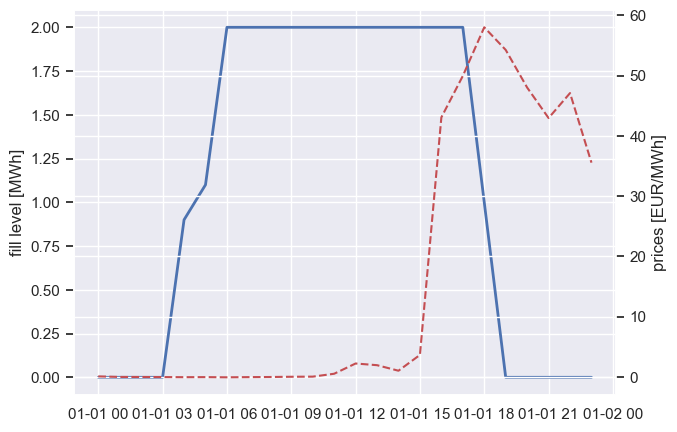

In [25]:
## show a graph of the battery fill level and prices
s = '2024-01-01' 
e = '2024-01-02'
sns.set_theme()
sns.color_palette("light:b", as_cmap=True)
sns.set_context("notebook") #talk, poster, notebook, paper
fig,ax = plt.subplots(figsize = (7,5))
ax2 = ax.twinx()
# h = sns.lineplot(data = out_id['internal_variables'].loc[s:e,:].reset_index(), x='index', y='battery_fill_level', 
#                  color='r', ax=ax,  label = 'ID', linewidth = 2)
i = sns.lineplot(data = out_dah['internal_variables'].loc[s:e,:].reset_index(), x='index', y='battery_fill_level', 
                 color='b', ax=ax,  label = 'DAH', linewidth = 2)
j = sns.lineplot(data = out_dah['prices'].loc[s:e,:].reset_index(), x='index', y='input data: dah', 
                 color='r', ax=ax2, label = 'DAH', linestyle='--')
# k = sns.lineplot(data = out_dah['prices'].loc[s:e,:].reset_index(), x='index', y='input data: id', 
#                  color='y', ax=ax2, label = 'ID', linestyle='--')
ax.set_xlabel(None)
ax.set_ylabel("fill level [MWh]")
ax2.set_ylabel("prices [EUR/MWh]")
# ax.legend(title= "Levels", loc='upper left')
# ax2.legend(title= "Prices", loc='upper right')
ax.legend_.remove() 
ax2.legend_.remove() 
plt.show()

Note that prices are very volatile. And the battery is used on a granular level as well. We may want to keep some fill level for extreme spikes. But in general we will want to utilize it every day.
* In general: Load during PV times, unload in the evening -- plus to balance out imbalances in RES production
* Note that we have many cycles across the year! 
* We can also introduce a parameter "max cycles" to restrict this (not shown) so battery lifetime is preserved

In [11]:
########## statistics
# number of cycles
cycles_dah = out_dah['internal_variables']['battery_charge'].sum() / battery_data['size'] * battery_data['eff']
cycles_id = out_id['internal_variables']['battery_charge'].sum() / battery_data['size'] * battery_data['eff']


print('Battery statistics over time frame of  ' + str(End-Start))
print('  - total cycles DAH: ' + f"{round(cycles_dah, 1):.6}")
print('  - total cycles  ID: ' + f"{round(cycles_id,1):.6}")


Battery statistics over time frame of  365 days 00:00:00
  - total cycles DAH: 365.0
  - total cycles  ID: 365.0


#### A simplified trading strategy: Optimize DAH and then reoptimize ID
Ideally, when prices change, we can earn extra money. Using our framework
* Optimize DAH
* Remember the dispatch -- since we have already sold it on the market
* With ID prices, try to optimize everything

In [12]:
######### get dispatch for DAH and add this to the input for ID optimization
pos_dah = pd.DataFrame(out_dah['dispatch']['dah']) # dah dispatch, position from dah optimization
pos_dah.rename(columns={'dah':'pos_dah'}, inplace=True)
data_com = pd.merge(data, pos_dah, left_index=True, right_index=True, how = 'left')
data_com.ffill(inplace=True)
data_com.head()
# new ID portfolio with position from dah
asset_pos_dah = eao.assets.SimpleContract(name    = 'pos_dah',
                                          nodes   = node_power,
                                          min_cap = 'pos_dah',
                                          max_cap = 'pos_dah')
portf_combined = eao.portfolio.Portfolio([id, battery, asset_pos_dah])
# optimization run
out_dah_id   = eao.optimize(portf_combined, timegrid=tg_id, data = data_com, split_interval_size='d') 


##### Perform optimization with new portfolio
(Tricky part is to handle the output data living on h/15min grids - optimization straight forward)

In [13]:
# put together results ---> result per run standalone or combined
dcf_combined = pd.merge(out_dah['DCF']/4, out_dah_id['DCF'], left_index=True, right_index=True, how = 'right') 
dcf_combined.ffill(inplace=True)
dcf_combined  = dcf_combined.sum(axis=1)
dcf_id_only   = out_id['DCF'].sum(axis=1)
dcf_dah       = out_dah['DCF'].sum(axis=1)

combined = (dcf_combined.resample('d').mean()*4) # EUR/MW/h
id_only  = (dcf_id_only.resample('d').mean()*4)
dah_only = (dcf_dah.resample('d').mean()) # hourly!
### filter out extremes
mm = 1e10 # large filter - inactive
II = (id_only < mm) & (combined < mm) & (dah_only < mm)

val_combined = combined[II].mean()
val_id_only  = id_only[II].mean()
val_dah_only = dah_only[II].mean()

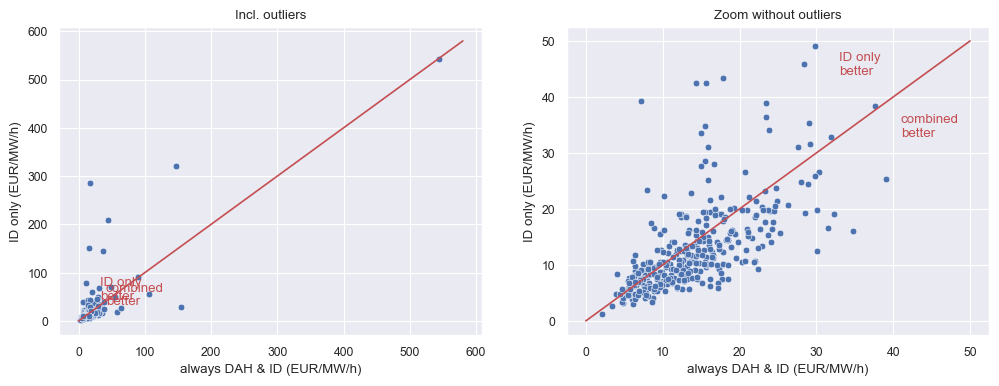

In [14]:
#### plot results
mm = 50
II = (combined < mm) & (id_only < mm)
sns.set_theme()
sns.color_palette("light:b", as_cmap=True)
sns.set_context("paper") #talk, poster, notebook, paper
tips = sns.load_dataset("tips")
fig,ax = plt.subplots(1, 2,figsize = (12,4))
###### Plot 1
mmm = 580
g = sns.scatterplot(x=combined, y=id_only, ax=ax[0])
h = sns.lineplot(x=[0,mmm], y=[0,mmm], color='r', ax=ax[0])
ax[0].set_xlabel("always DAH & ID (EUR/MW/h)")
ax[0].set_ylabel("ID only (EUR/MW/h)")
ax[0].text(41, 33, 'combined\nbetter', color = 'r')
ax[0].text(33, 44, 'ID only\nbetter', color = 'r')
ax[0].set_title('Incl. outliers')
###### Plot 2
g = sns.scatterplot(x=combined[II], y=id_only[II], ax=ax[1])
h = sns.lineplot(x=[0,mm], y=[0,mm], color='r', ax=ax[1])
ax[1].set_xlabel("always DAH & ID (EUR/MW/h)")
ax[1].set_ylabel("ID only (EUR/MW/h)")
ax[1].text(41, 33, 'combined\nbetter', color = 'r')
ax[1].text(33, 44, 'ID only\nbetter', color = 'r')
ax[1].set_title('Zoom without outliers')
###########
plt.show()

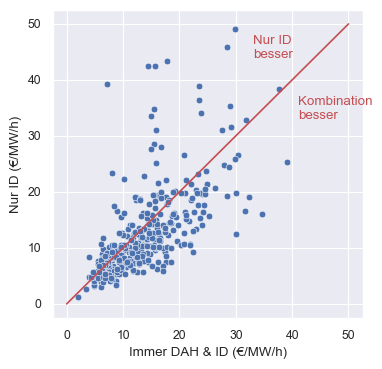

In [15]:
### scatter FCR vs. id
mm = 50
II = (combined < mm) & (id_only < mm)
sns.set_theme()
sns.color_palette("light:b", as_cmap=True)
sns.set_context("paper") #talk, poster, notebook, paper
tips = sns.load_dataset("tips")
fig,ax = plt.subplots(figsize = (4,4))
g = sns.scatterplot(x=combined[II], y=id_only[II], ax=ax)
h = sns.lineplot(x=[0,mm], y=[0,mm], color='r', ax=ax)

ax.set_xlabel("Immer DAH & ID (€/MW/h)")
ax.set_ylabel("Nur ID (€/MW/h)")
ax.text(41, 33, 'Kombination\nbesser', color = 'r')
ax.text(33, 44, 'Nur ID\nbesser', color = 'r')

plt.savefig('FCR_vs_Arbitrage.png', dpi=300, bbox_inches='tight')
plt.show()

Beware of extremes: With outliers on the left we see that there are some extreme cases where "ID only" would have been the best strategy. However, the zoom (right) shows, that in most cases it's the combined strategy. It becomes clear that a notion of certainty is a relevant input to the strategy.

A forecast, which strategy is best on which day can boost profitability.

### A different market: Reserve (here FCR)
Compare returns from arbitrage to FCR. As above it becomes clear that there is no general answer -- a good forecast can increase profitability.

The bigger the battery, the better arbitrage performs vs. FCR.

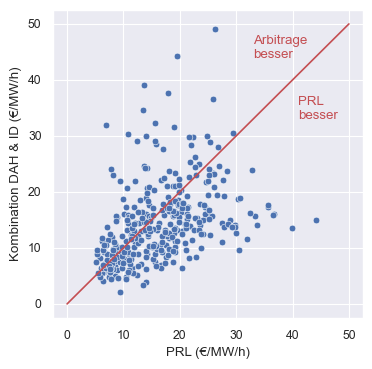

In [16]:
### scatter FCR vs. id
mm = 50
II = (data_FCR < mm) & (combined < mm)
sns.set_theme()
sns.color_palette("light:b", as_cmap=True)
sns.set_context("paper") #talk, poster, notebook, paper
tips = sns.load_dataset("tips")
fig,ax = plt.subplots(figsize = (4,4))
g = sns.scatterplot(x=data_FCR[II], y=combined[II])
h = sns.lineplot(x=[0,mm], y=[0,mm], color='r', ax=ax)
# ax.set_xlabel('FCR (EUR/MW/h)')
# ax.set_ylabel("DAH & ID combined (EUR/MW/h)")
# ax.text(41, 33, 'FCR\nbetter', color = 'r')
# ax.text(33, 44, 'arbitrage\nbetter', color = 'r')
ax.set_xlabel('PRL (€/MW/h)')
ax.set_ylabel("Kombination DAH & ID (€/MW/h)")
ax.text(41, 33, 'PRL\nbesser', color = 'r')
ax.text(33, 44, 'Arbitrage\nbesser', color = 'r')

plt.savefig('FCR_vs_Arbitrage.png', dpi=300, bbox_inches='tight')
plt.show()

### Illustration: How do returns increase with battery size (in FLH)?
Simple to iterate over parameter (but takes some time... in this case ~10min)

In [17]:
storage_sizes = [1,2,3, 4, 5, 6]
values = [] # collect results

for my_size in storage_sizes:
    print('Optimizing with storage size: ' + str(my_size) + ' MWh')
    myportf = eao.io.set_param(portf_id, ['assets', 1, 'size'], my_size )
    out_dah = eao.optimize(myportf, timegrid=tg_id, data = data, split_interval_size='d') # weekly optimization
    values.append(out_dah['summary'].loc['value','Values']/battery_data['cap']/((End-Start).days*24))

Optimizing with storage size: 1 MWh
Optimizing with storage size: 2 MWh
Optimizing with storage size: 3 MWh
Optimizing with storage size: 4 MWh
Optimizing with storage size: 5 MWh
Optimizing with storage size: 6 MWh


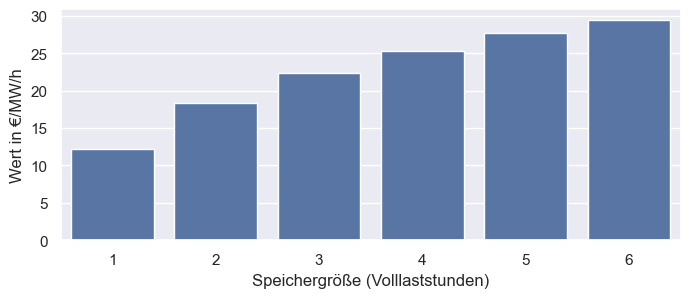

In [18]:
sns.set_theme()
sns.color_palette("light:b", as_cmap=True)
sns.set_context("notebook") #talk, poster, notebook, paper
fig,ax = plt.subplots(figsize = (8,3))
h = sns.barplot(x=storage_sizes, y=values, color='b', ax=ax)
#ax.set_xlabel('storage size (full load hours)')
ax.set_xlabel('Speichergröße (Volllaststunden)')
#ax.set_ylabel("value in EUR/MW/h")
ax.set_ylabel("Wert in €/MW/h")
plt.savefig('value_vs_size.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
cycles = [1,2,3,4,5]
values_c = [] # collect results

for my_cyc in cycles:
    print('Optimizing with max. cycles: ' + str(my_cyc) + ' per day')
    myportf = eao.io.set_param(portf_id, ['assets', 1, 'size'], battery_data['size'] )
    myportf = eao.io.set_param(portf_id, ['assets', 1, 'max_cycles_freq'], 'd')
    myportf = eao.io.set_param(myportf, ['assets', 1, 'max_cycles_no'], my_cyc)
    out_dah = eao.optimize(myportf, timegrid=tg_id, data = data, split_interval_size='d') # weekly optimization
    values_c.append(out_dah['summary'].loc['value','Values']/battery_data['cap']/((End-Start).days*24))  

Optimizing with max. cycles: 1 per day
Optimizing with max. cycles: 2 per day
Optimizing with max. cycles: 3 per day
Optimizing with max. cycles: 4 per day
Optimizing with max. cycles: 5 per day


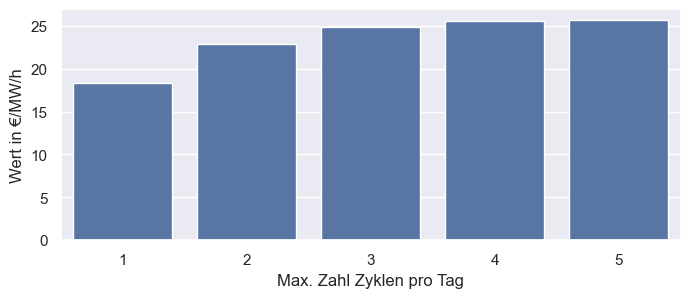

In [20]:
sns.set_theme()
sns.color_palette("light:b", as_cmap=True)
sns.set_context("notebook") #talk, poster, notebook, paper
fig,ax = plt.subplots(figsize = (8,3))
h = sns.barplot(x=cycles, y=values_c, color='b', ax=ax)
#ax.set_xlabel('number cycles allowed per day')
ax.set_xlabel('Max. Zahl Zyklen pro Tag')
#ax.set_ylabel("value in EUR/MW/h")
ax.set_ylabel("Wert in €/MW/h")
plt.savefig('value_vs_cycles.png', dpi=300, bbox_inches='tight')
plt.show()